# Task 1: Exploring and Visualizing the Iris Dataset
**Internship:** DevelopersHub Corporation — AI/ML Engineering  
**Objective:** Load, inspect, and visualize the Iris dataset to understand data trends and distributions.  
**Dataset:** Iris (loaded via seaborn / sklearn)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Display settings
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Inspect the Dataset

In [2]:
# Load the Iris dataset
iris = load_iris(as_frame=True)
df = iris.frame

# Replace numeric target with species names for readability
df["species"] = pd.Categorical.from_codes(df["target"], iris.target_names)
df.drop(columns=["target"], inplace=True)

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Shape: (150, 5)

Column Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

First 5 Rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Dataset info
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [4]:
# Descriptive statistics
print("=== Descriptive Statistics ===")
df.describe().round(2)

=== Descriptive Statistics ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [5]:
# Class distribution
print("=== Species Distribution ===")
print(df["species"].value_counts())

=== Species Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Data Visualization

### 3a. Scatter Plot — Sepal Length vs Sepal Width

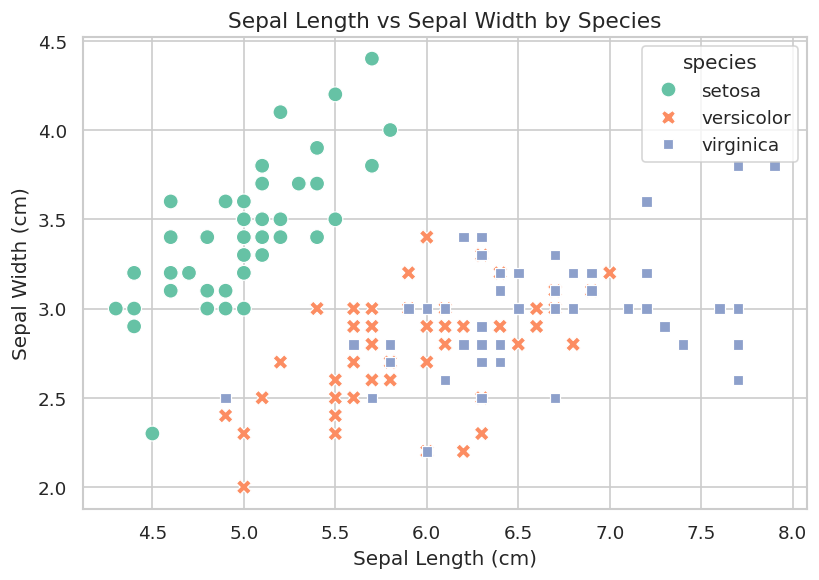

Plot saved.


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="sepal length (cm)", y="sepal width (cm)",
                hue="species", style="species", s=80, ax=ax)
ax.set_title("Sepal Length vs Sepal Width by Species", fontsize=13)
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Sepal Width (cm)")
plt.tight_layout()
plt.savefig("task1_scatter_sepal.png")
plt.show()
print("Plot saved.")

### 3b. Scatter Plot — Petal Length vs Petal Width

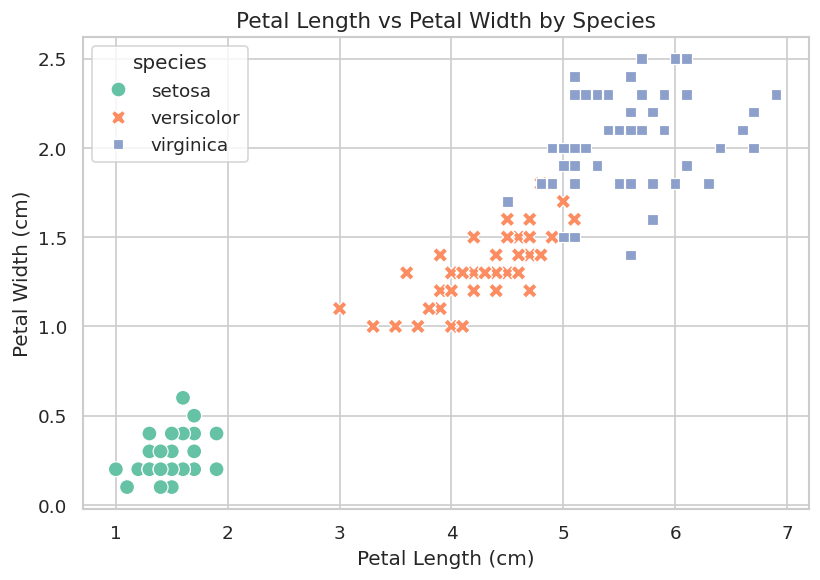

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)",
                hue="species", style="species", s=80, ax=ax)
ax.set_title("Petal Length vs Petal Width by Species", fontsize=13)
ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Petal Width (cm)")
plt.tight_layout()
plt.savefig("task1_scatter_petal.png")
plt.show()

### 3c. Pair Plot — All Feature Relationships

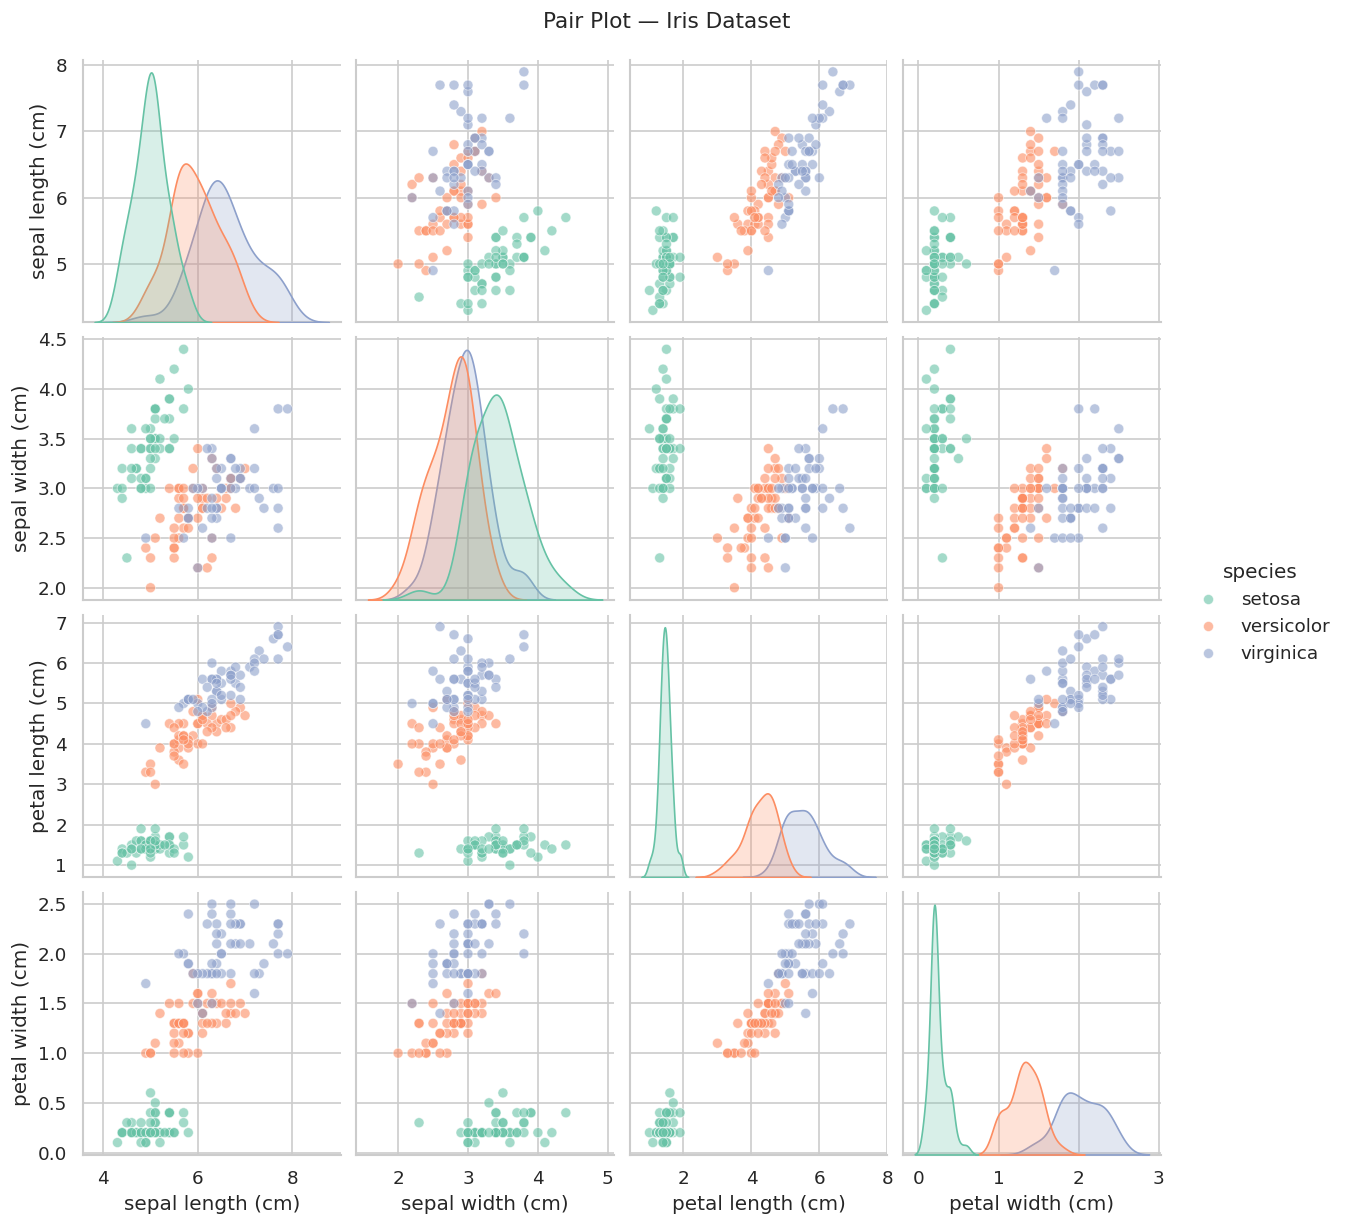

In [8]:
pair_plot = sns.pairplot(df, hue="species", diag_kind="kde", plot_kws={"alpha": 0.6})
pair_plot.figure.suptitle("Pair Plot — Iris Dataset", y=1.02, fontsize=13)
plt.savefig("task1_pairplot.png", bbox_inches="tight")
plt.show()

### 3d. Histograms — Feature Value Distributions

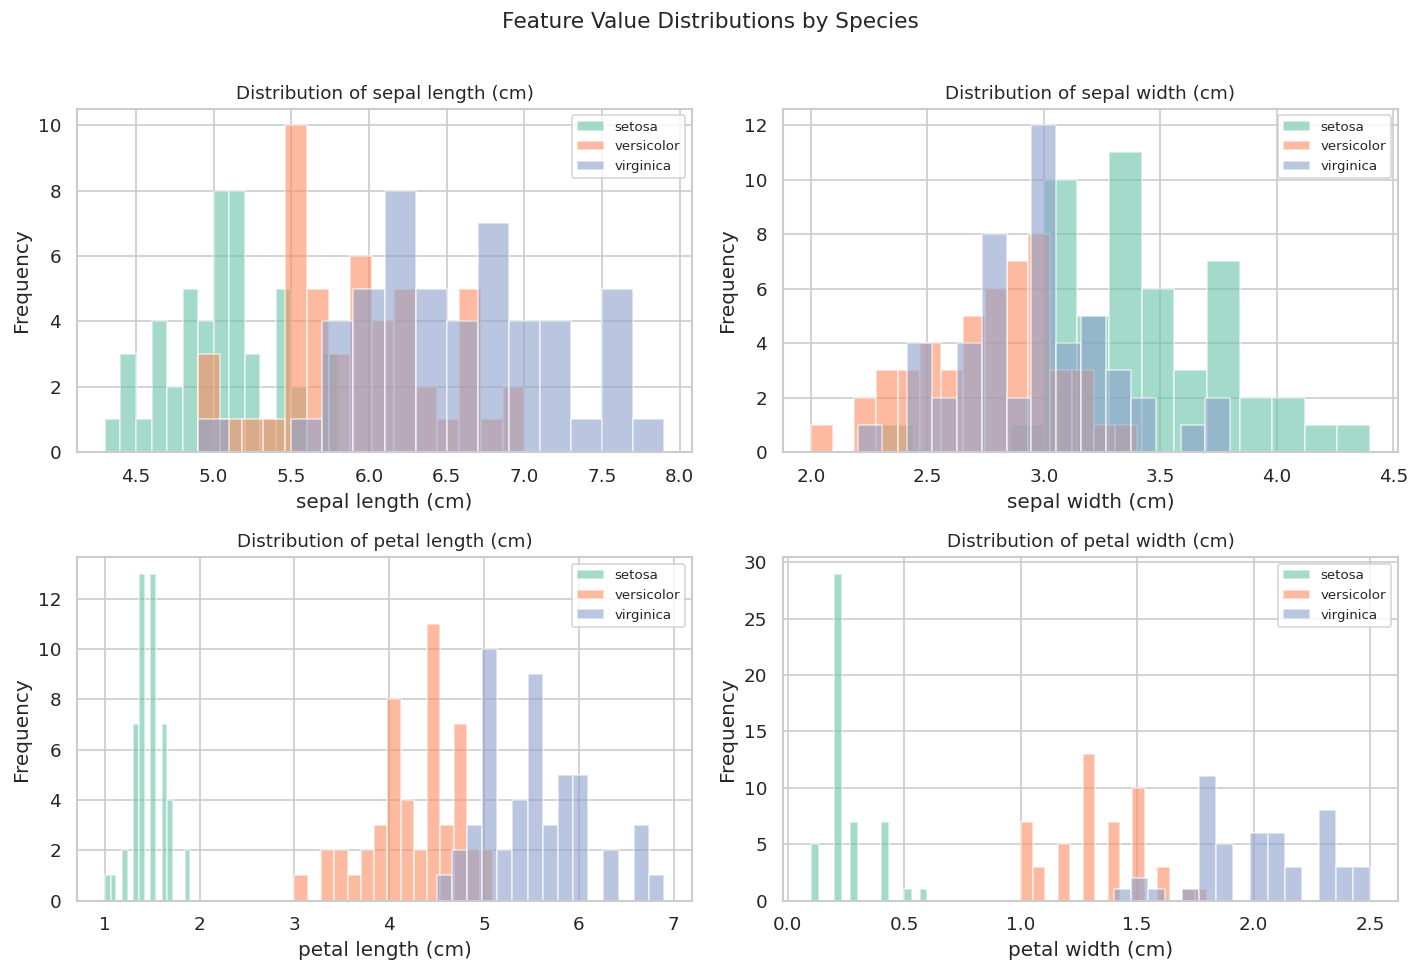

In [9]:
features = ["sepal length (cm)", "sepal width (cm)",
            "petal length (cm)", "petal width (cm)"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for species in df["species"].unique():
        subset = df[df["species"] == species][feat]
        axes[i].hist(subset, bins=15, alpha=0.6, label=species)
    axes[i].set_title(f"Distribution of {feat}", fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Value Distributions by Species", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("task1_histograms.png", bbox_inches="tight")
plt.show()

### 3e. Box Plots — Identifying Outliers

/tmp/ipykernel_79116/1297898674.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feat, ax=axes[i], palette="Set2")
/tmp/ipykernel_79116/1297898674.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feat, ax=axes[i], palette="Set2")
/tmp/ipykernel_79116/1297898674.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feat, ax=axes[i], palette="Set2")
/tmp/ipykernel_79116/1297898674.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

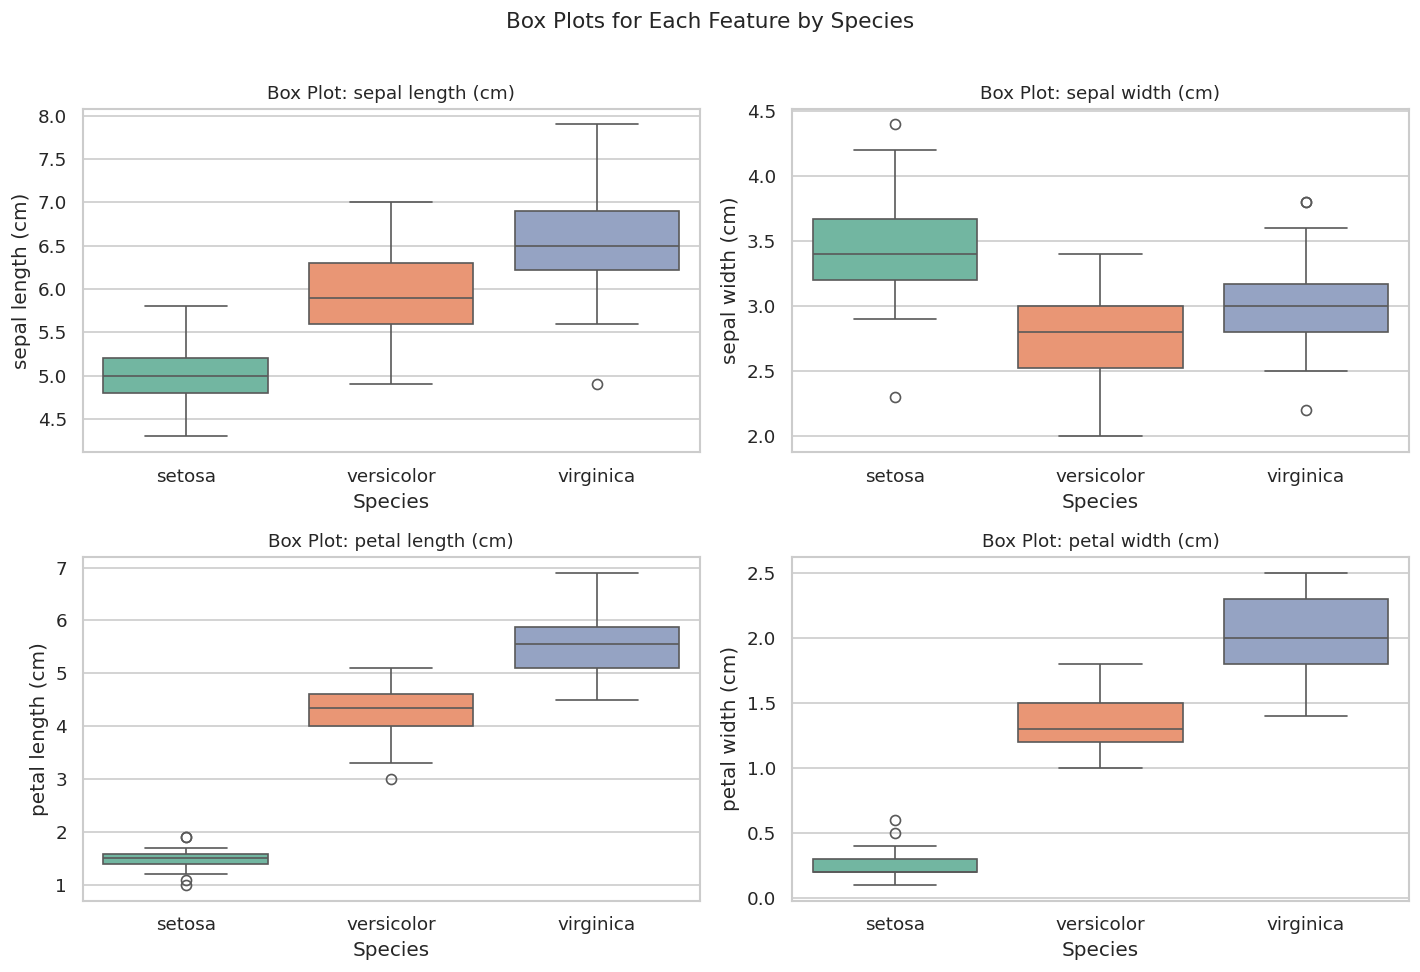

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df, x="species", y=feat, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Box Plot: {feat}", fontsize=11)
    axes[i].set_xlabel("Species")
    axes[i].set_ylabel(feat)

plt.suptitle("Box Plots for Each Feature by Species", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("task1_boxplots.png", bbox_inches="tight")
plt.show()

### 3f. Correlation Heatmap

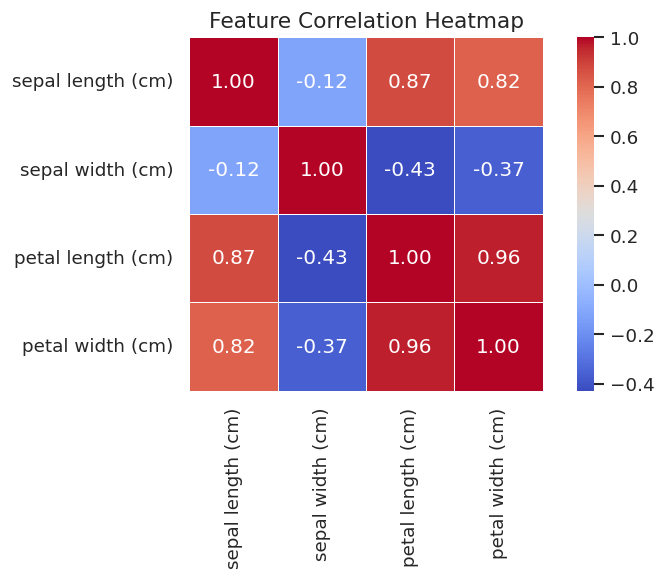

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.savefig("task1_heatmap.png")
plt.show()

## 4. Key Insights & Findings

1. **Setosa is clearly separable** from the other two species using petal length and petal width alone — even a simple threshold rule works.
2. **Versicolor and Virginica overlap** slightly in sepal measurements but are better separated by petal dimensions.
3. **Petal length and petal width are highly correlated** (r ≈ 0.96), indicating redundancy — one could be dropped in modeling.
4. **Sepal width shows the most outliers** (especially in Setosa), visible in the box plots.
5. **All features increase in scale** from Setosa → Versicolor → Virginica on average, making species classification learnable.

---
*Task 1 Complete — DevelopersHub AI/ML Internship*